# Train CNN: AD vs CN, axial slice 23 (VGG19_BN, FocalLoss)

First CNN training run of the 2026 re-run. Single orientation/slice as a first pass before
running coronal (43) and sagittal (26) separately to build the full ADxCN ensemble input.

- **Model:** `vgg19_bn` — the dissertation's actual final backbone (every `notebooks/final_studies/`
  notebook reads `PREDICTIONS_AD_VGG19_BN.csv`, not resnet34).
- **Loss:** `FocalLoss`, `gamma=2` — no historical AD/CN FocalLoss run exists to copy a gamma from;
  MCIxCN runs always used `gamma=2` (occasionally testing 5), which also matches `WeightedFocalLoss`'s
  library default.
- **Input:** `data/reference/PROCESSED_MRI_REFERENCE_ALL_ORIENTATIONS_20260710_1413.csv` — all 7287
  images sliced (Step 8), `DATASET` covering the full CNN training cohort (not just the
  cognitively-complete subset the ensemble uses).
- **Output:** `.pth` weights under `models/`, predictions CSV at `data/PREDICTIONS_AD_VGG19_BN_axial.csv`.

Two real bugs in `mri_train.py` were patched this session before this run:
1. `additional_experiment_params` needs an explicit `'loss'` (+`'loss_gamma'` for FocalLoss) key —
   passed explicitly below either way.
2. The save-skip bug at the end of `train()` (only saved the model if the single best epoch happened
   to be literally the last epoch) — fixed to save unconditionally after the training loop.

In [1]:
import os
import sys

REPO_ROOT = "/home/lucasthim/projects/phd/mmml-alzheimer-diagnosis"

# mri_train.py's own internal imports (`sys.path.append("./../models")` etc.) are CWD-relative,
# not __file__-relative -- CWD must be src/model_training/ for them to resolve.
os.chdir(os.path.join(REPO_ROOT, "src/model_training"))
sys.path.insert(0, os.getcwd())

import pandas as pd
from mri_train import run_experiments_for_ensemble

print("CWD:", os.getcwd())

Using cuda device
CWD: /home/lucasthim/projects/phd/mmml-alzheimer-diagnosis/src/model_training


## Config

All data/model paths are absolute (built from `REPO_ROOT`) so they stay correct after the `chdir` above.

In [ ]:
orientation_and_slices = [("axial", [23])]   # AD's designated axial slice
classes = ["AD", "CN"]

mri_config = {
    "num_samples": 0,      # no neighbor-slice sampling -- only slice 23 exists on disk for this orientation/class
    "num_rotations": 0,    # rotation-only augmentation, traced from the actual executed 2021 notebook cells
    "sampling_range": 0,
    "mri_reference": os.path.join(REPO_ROOT, "data/reference/PROCESSED_MRI_REFERENCE_ALL_ORIENTATIONS_20260710_1413.csv"),
    # generate_mri_dataset_reference's output_path -- only ever used with save_reference_file=False in this
    # call path (run_experiments_for_ensemble line ~154), so nothing is actually written here; it's just where
    # os.makedirs would land if that ever changed. Reusing data/reference/ rather than inventing a new dir --
    # confirmed this path never duplicates .npz pixel data, only a small reference CSV would go here.
    "output_path": os.path.join(REPO_ROOT, "data/reference/"),
}

additional_experiment_params = {
    "lr": 0.0001,                 # traced ADxCN BCE config; first thing to lower if AUC collapses to 0.5
    "batch_size": 16,
    "optimizer": "adam",
    "max_epochs": 100,
    "early_stop": 10,
    "early_stop_metric": "auc",
    "prediction_threshold": 0.5,
    "loss": "BCE",
    # "loss_gamma": 2,              # no AD/CN precedent; matches WeightedFocalLoss's library default and MCIxCN's usual value
}

model_path = os.path.join(REPO_ROOT, "models/vgg19_bn")   # -> models/vgg19_bn_axial_23cnn_axial_23<timestamp>.pth
save_path = os.path.join(REPO_ROOT, "data/PREDICTIONS_AD_VGG19_BN_axial.csv")

## Train


--------------------------------------------------------------------
--------------------------------------------------------------------
Running axial - slice:23 with no data augmentation.
--------------------------------------------------------------------
--------------------------------------------------------------------

Creating augmented samples...
Creating final reference file for prepared images...
Loading untrained model...
Setting up experiment parameters...
Train size: 3703
Validation size: 291
Test size: 270

---------------------------------------------------------------------
Running Epoch 1 of  100
Loss::      Train 0.0861      Validation 0.0032
AUC::       Train 0.5377      Validation 0.5592
Accuracy::  Train 0.5039      Validation 0.4914
F1::        Train 0.4465      Validation 0.3211
Precision:: Train 0.3554      Validation 0.2083
Recall::    Train 0.6005      Validation 0.7000
Validation Confusion Matrix:
 [[108 133]
 [ 15  35]]

Epoch 1 took 8.89 seconds
--------

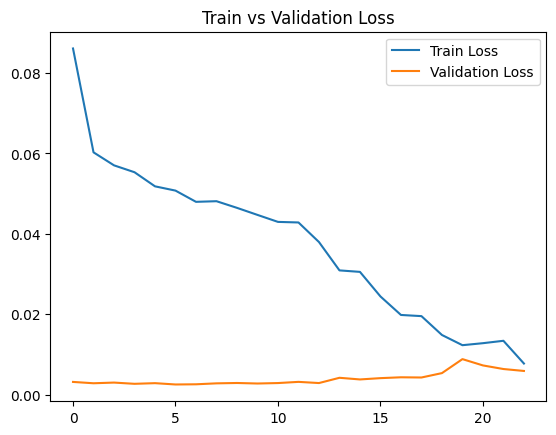

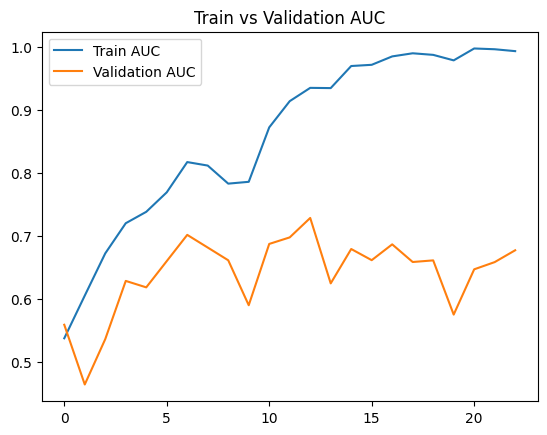

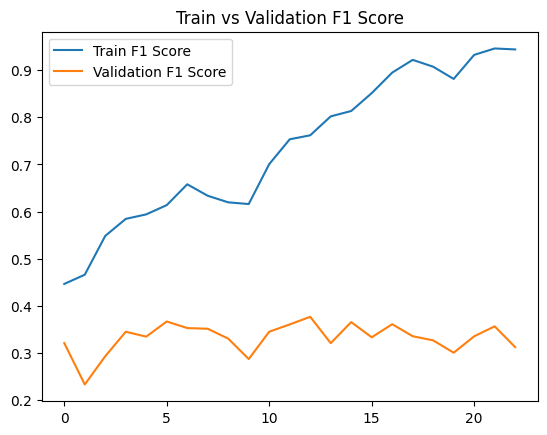


-------------------------------
Best metrics for validation set on Epoch 13:
Loss::      0.0029
AUC::       0.7284
Accuracy::  0.5567
F1::        0.3768
Precision:: 0.2484
Recall::    0.7800
Confusion Matrix:
 [[123 118]
 [ 11  39]]
-------------------------------

Metrics for train set on Epoch 13:
Loss::      0.0380
AUC::       0.9345
Accuracy::  0.7999
F1::        0.7617
Precision:: 0.6315
Recall::    0.9595
Confusion Matrix:
 [[1778  691]
 [  50 1184]]
-------------------------------

Loading untrained model...
Loading trained weights into current model...
Train size: 3703
Validation size: 291
Test size: 270

Training set:
----------------
Total samples in batch: (3703, 1)
AUC:       0.956
Accuracy:  0.824
F1:        0.787
Precision: 0.660
Recall:    0.974
Confusion Matrix: 
 [[1850  619]
 [  32 1202]]
----------------

Validation set:
----------------
Total samples in batch: (291, 1)
AUC:       0.746
Accuracy:  0.687
F1:        0.420
Precision: 0.308
Recall:    0.660
Confusion Ma

In [3]:
df_predictions = run_experiments_for_ensemble(
    orientation_and_slices=orientation_and_slices,
    model=model,
    classes=classes,
    mri_config=mri_config,
    additional_experiment_params=additional_experiment_params,
    save_path=save_path,
    model_path=model_path,
)

In [8]:
df_predictions.shape

(15373, 16)

In [9]:
df_predictions.head()

,SUBJECT,IMAGE_DATA_ID,ORIENTATION,SLICE,VALID_IMAGE,GROUP,MACRO_GROUP,SEX,AGE,IMAGE_PATH,ORIGINAL_IMAGE_PATH,DATASET,MAIN_SLICE,SLICE_ID,ROTATION_ANGLE,CNN_SCORE
0,941_S_7051,I1553005,axial,23,True,CN,0,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train,23,I1553005_23,-15,0.453423
1,941_S_7051,I1553005,axial,23,True,CN,0,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train,23,I1553005_23,13,0.424489
2,941_S_7051,I1553005,axial,23,True,CN,0,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train,23,I1553005_23,-5,0.334089
3,941_S_7051,I1553005,axial,23,True,CN,0,1.0,64.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train,23,I1553005_23,0,0.460787
20,141_S_6240,I974280,axial,23,True,CN,0,1.0,67.0,/home/lucasthim/projects/phd/mmml-alzheimer-di...,/mnt/d/lucas/Downloads/preprocessed/20260709/A...,train,23,I974280_23,15,0.211150
